In [12]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import roc_auc_score
pd.set_option('display.float_format', '{:.2f}'.format)

In [13]:
# 학습, 테스트 데이터 불러오기
train_df = pd.read_csv("../data/santander-customer-satisfaction/train.csv", index_col=0)

# target 데이터 분리
X_features = train_df.drop('TARGET', axis=1)
y_labels = train_df['TARGET']
print(f'X_features.shape{X_features.shape}, y_labels.shape{y_labels.shape}', end=' ')


X_features.shape(76020, 369), y_labels.shape(76020,) 

In [14]:
X_features.describe().T


,count,mean,std,min,25%,50%,75%,max
var3,76020.00,-1523.20,39033.46,-999999.00,2.00,2.00,2.00,238.00
var15,76020.00,33.21,12.96,5.00,23.00,28.00,40.00,105.00
imp_ent_var16_ult1,76020.00,86.21,1614.76,0.00,0.00,0.00,0.00,210000.00
imp_op_var39_comer_ult1,76020.00,72.36,339.32,0.00,0.00,0.00,0.00,12888.03
imp_op_var39_comer_ult3,76020.00,119.53,546.27,0.00,0.00,0.00,0.00,21024.81
...,...,...,...,...,...,...,...,...
saldo_medio_var44_hace2,76020.00,31.51,2013.13,0.00,0.00,0.00,0.00,438329.22
saldo_medio_var44_hace3,76020.00,1.86,147.79,0.00,0.00,0.00,0.00,24650.01
saldo_medio_var44_ult1,76020.00,76.03,4040.34,0.00,0.00,0.00,0.00,681462.90
saldo_medio_var44_ult3,76020.00,56.61,2852.58,0.00,0.00,0.00,0.00,397884.30


In [15]:
# -----------------------------------------------------------------------------------------------------

# var3 컬럼의 이상치(-999999)를 최빈값 2로 대체
print('치환 전 -999999 개수:', (X_features['var3'] == -999999).sum())
X_features['var3'] = X_features['var3'].replace(-999999, 2)
print('치환 후 -999999 개수:', (X_features['var3'] == -999999).sum())

치환 전 -999999 개수: 116
치환 후 -999999 개수: 0


In [16]:
# -----------------------------------------------------------------------------------------------------

# 결측치 확인
print('결측치 총 개수:', X_features.isnull().sum().sum())

결측치 총 개수: 0


In [17]:
X_features.describe().T.sort_values('max', ascending=False) # .T => 행과 열을 바꿔서 보여줌

,count,mean,std,min,25%,50%,75%,max
delta_imp_amort_var18_1y3,76020.00,263088.66,51291831.71,0.00,0.00,0.00,0.00,9999999999.00
delta_num_venta_var44_1y3,76020.00,5524861.88,234986852.92,-1.00,0.00,0.00,0.00,9999999999.00
delta_num_compra_var44_1y3,76020.00,9208103.13,303310817.97,-1.00,0.00,0.00,0.00,9999999999.00
delta_num_reemb_var13_1y3,76020.00,4998684.56,223522965.12,0.00,0.00,0.00,0.00,9999999999.00
delta_num_reemb_var17_1y3,76020.00,2630886.61,162179809.19,-1.00,0.00,0.00,0.00,9999999999.00
...,...,...,...,...,...,...,...,...
num_reemb_var13_hace3,76020.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
saldo_var2_ult1,76020.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ind_var2_0,76020.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ind_var2,76020.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [189]:
# delta_* 계열 컬럼에 남아있는 9999999999(비정상 값) 처리
delta_cols = [c for c in X_features.columns if c.startswith('delta_')]
suspicious = (X_features[delta_cols] == 9999999999).sum()
suspicious = suspicious[suspicious > 0]
print('처리 전 9999999999 값을 가진 delta_* 컬럼 수:', len(suspicious))

# 9999999999는 결측/해당없음을 나타내는 값으로 보임 (정상값은 대부분 -1~1.5 범위, 중앙값 0)
# -> NaN으로 바꾼 뒤 각 컬럼의 중앙값으로 대체
X_features[delta_cols] = X_features[delta_cols].replace(9999999999, np.nan)
X_features[delta_cols] = X_features[delta_cols].fillna(X_features[delta_cols].median())

# 다시 확인
remaining = (X_features[delta_cols] == 9999999999).sum().sum()
print('처리 후 9999999999 남은 개수:', remaining)
print('처리 후 결측치 개수:', X_features[delta_cols].isnull().sum().sum())

처리 전 9999999999 값을 가진 delta_* 컬럼 수: 26
처리 후 9999999999 남은 개수: 0
처리 후 결측치 개수: 0


In [190]:
# var38이 오른쪽으로 심하게 치우쳐 있어서(왜도 51.27) 로그 변환으로 완화
# 2026-08-20 19:28 적용
X_features['var38'] = np.log1p(X_features['var38'])

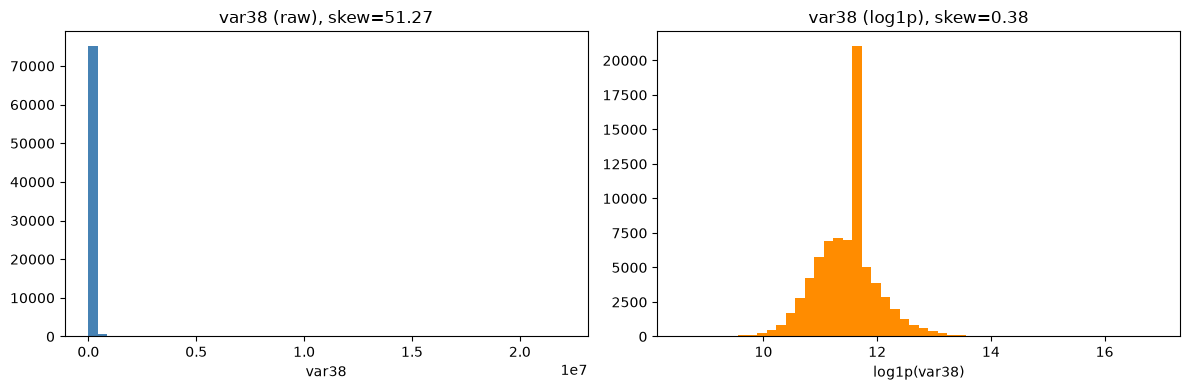

In [191]:
# var38 로그 변환 전/후 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df['var38'], bins=50, color='steelblue')
axes[0].set_title(f"var38 (raw), skew={train_df['var38'].skew():.2f}")
axes[0].set_xlabel('var38')

axes[1].hist(X_features['var38'], bins=50, color='darkorange')
axes[1].set_title(f"var38 (log1p), skew={X_features['var38'].skew():.2f}")
axes[1].set_xlabel('log1p(var38)')

plt.tight_layout()
plt.show()

In [192]:
# n0, PCA1~PCA5 파생 피처 추가
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

# 행마다 값이 0인 컬럼 개수
X_features['n0'] = (X_features == 0).sum(axis=1)

X_normalized = normalize(X_features, axis=0)
# ▼▼▼ [수정 전 - 이전 설정, 주석 처리됨] ▼▼▼ (실측 AUC 0.8236)
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_normalized)
# pca_df = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1]}, index=X_features.index)
# PCA 컴포넌트 2개 -> 5개로 증가 (실측 AUC 0.8236 -> 0.8242)
n_components = 5
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_normalized)
pca_df = pd.DataFrame({f'PCA{i+1}': X_pca[:, i] for i in range(n_components)}, index=X_features.index)
X_features = pd.concat([X_features, pca_df], axis=1)

C:\Users\mega\AppData\Local\Temp\ipykernel_5868\2528823153.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_features['n0'] = (X_features == 0).sum(axis=1)


In [193]:
#학습/테스트 데이터 분리, 분포 확인
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels,
                                                    test_size=0.2, random_state=0, 
                                                    stratify=y_labels
                                                    )
train_cnt = y_train.count()
test_cnt = y_test.count()
print('학습 세트 Shape:{0}, 테스트 세트 Shape:{1}'.format(X_train.shape , X_test.shape))

print(' 학습 세트 레이블 값 분포 비율')
print(y_train.value_counts()/train_cnt)
print('\n 테스트 세트 레이블 값 분포 비율')
print(y_test.value_counts()/test_cnt)

학습 세트 Shape:(60816, 375), 테스트 세트 Shape:(15204, 375)
 학습 세트 레이블 값 분포 비율
TARGET
0    0.960438
1    0.039562
Name: count, dtype: float64

 테스트 세트 레이블 값 분포 비율
TARGET
0    0.960405
1    0.039595
Name: count, dtype: float64


In [194]:
# X_train, y_train을 다시 학습과 검증 데이터 세트로 분리.
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train,
                                                    test_size=0.3, random_state=0, 
                                                    stratify=y_train
                                                    )


In [195]:
# XGB모델 학습 AUC 점수 확인
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# n_estimators는 500으로, learning_rate 0.05, random state는 예제 수행 시마다 동일 예측 결과를 위해 설정.
# ▼▼▼ [수정 전 - 이전 설정, 주석 처리됨] ▼▼▼ (실측 AUC 0.8236)
# xgb_clf = XGBClassifier(n_estimators=500, learning_rate=0.05, early_stopping_rounds=100, eval_metric='auc',random_state=156)
# max_depth=4, subsample=0.8, colsample_bytree=0.5 : 과적합 완화용 정규화 조합 (실측 AUC 0.8236 -> 0.8256)
xgb_clf = XGBClassifier(n_estimators=500, learning_rate=0.05, early_stopping_rounds=100, eval_metric='auc',
                        random_state=156, 
                        # max_depth=4, subsample=0.8, colsample_bytree=0.5
                        )

# 성능 평가 지표를 auc로, 조기 중단 파라미터는 100으로 설정하고 학습 수행.
xgb_clf.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)])

xgb_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1])
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.84574	validation_1-auc:0.81977
[1]	validation_0-auc:0.85237	validation_1-auc:0.82634
[2]	validation_0-auc:0.85371	validation_1-auc:0.82830
[3]	validation_0-auc:0.85508	validation_1-auc:0.82991
[4]	validation_0-auc:0.85719	validation_1-auc:0.83212
[5]	validation_0-auc:0.85767	validation_1-auc:0.83342
[6]	validation_0-auc:0.85856	validation_1-auc:0.83337
[7]	validation_0-auc:0.85918	validation_1-auc:0.83365
[8]	validation_0-auc:0.85962	validation_1-auc:0.83532
[9]	validation_0-auc:0.86350	validation_1-auc:0.83834
[10]	validation_0-auc:0.86463	validation_1-auc:0.83897
[11]	validation_0-auc:0.86592	validation_1-auc:0.83948
[12]	validation_0-auc:0.86644	validation_1-auc:0.83999
[13]	validation_0-auc:0.86691	validation_1-auc:0.84042
[14]	validation_0-auc:0.86725	validation_1-auc:0.84054
[15]	validation_0-auc:0.86806	validation_1-auc:0.84091
[16]	validation_0-auc:0.86931	validation_1-auc:0.84137
[17]	validation_0-auc:0.87029	validation_1-auc:0.84184
[18]	validation_0-au

중요도 상위 20개 피처:
saldo_var30                0.137366
var15                      0.061593
saldo_var8                 0.039631
num_meses_var5_ult3        0.031369
num_var42_0                0.018957
num_meses_var8_ult3        0.018082
ind_var5                   0.015758
var3                       0.014412
saldo_medio_var5_hace2     0.014198
num_var22_ult1             0.013437
saldo_medio_var5_ult1      0.011883
var38                      0.010965
ind_var8_0                 0.010651
num_op_var39_hace2         0.010644
PCA2                       0.010263
ind_var9_cte_ult1          0.010134
imp_trans_var37_ult1       0.009994
num_var22_ult3             0.009899
n0                         0.009879
imp_op_var41_efect_ult1    0.009774
dtype: float32


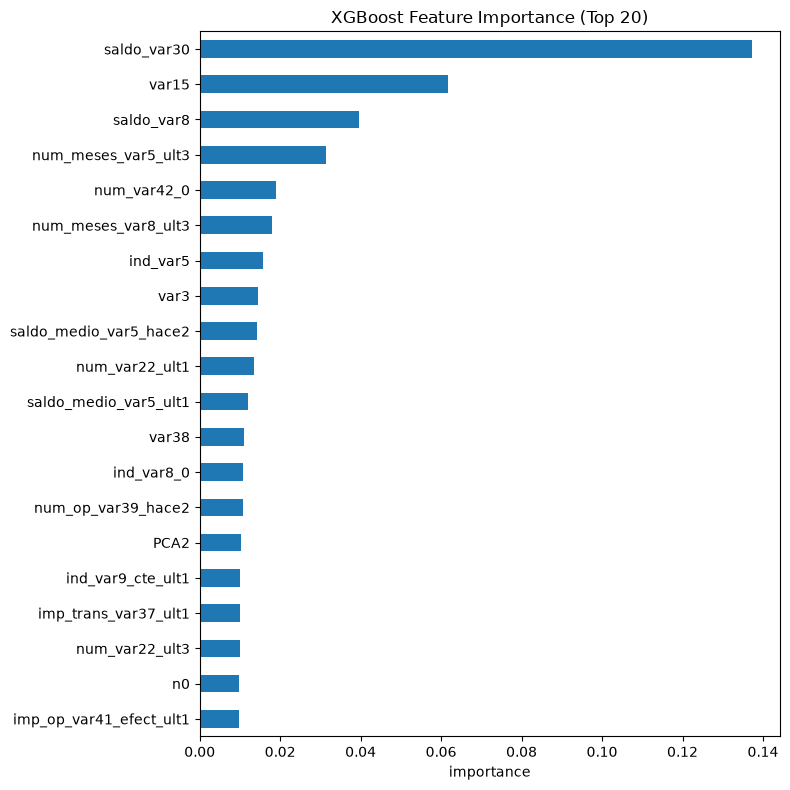

In [196]:
# --- 가지치기 하기 전에 feature importance 먼저 확인 ---
# xgb_clf.feature_importances_ : 학습된 모델이 각 피처를 트리 분기(split)에서
# 얼마나 많이/중요하게 썼는지를 0~1 사이 비중으로 알려준다 (전체 합 = 1).
importance_series = pd.Series(xgb_clf.feature_importances_, index=X_tr.columns).sort_values(ascending=False)

print('중요도 상위 20개 피처:')
print(importance_series.head(20))

# 상위 20개를 막대그래프로 시각화 (중요도 높은 게 위로 오게 정렬)
plt.figure(figsize=(8, 8))
importance_series.head(20)[::-1].plot(kind='barh')
plt.title('XGBoost Feature Importance (Top 20)')
plt.xlabel('importance')
plt.tight_layout()
plt.show()

In [197]:
# --- (JHcode.ipynb 아이디어 적용) importance=0인 피처를 사후에 가지치기 ---
# 위에서 학습한 xgb_clf가 실제로 "한 번이라도 분기(split) 기준으로 쓴" 피처만 걸러낸다.
# XGBoost 같은 트리 모델은 트리를 만들 때 각 피처가 몇 번 split에 쓰였는지를
# feature_importances_로 알려주는데, 이 값이 0이라는 건 그 피처가 트리 구조에
# 전혀 영향을 주지 않았다는 뜻이라 지워도 예측 결과가 (거의) 똑같이 나온다.
# -> 정확도를 올리는 목적이 아니라, 점수는 유지하면서 모델을 가볍게 만드는 목적.
importances = pd.Series(xgb_clf.feature_importances_, index=X_tr.columns)
zero_importance_cols = importances[importances == 0].index.tolist()
kept_features = importances[importances > 0].index.tolist()

print(f'전체 피처 수: {len(importances)}')
print(f'importance=0 (한 번도 안 쓰인 피처): {len(zero_importance_cols)}개')
print(f'importance>0 (실제로 쓰인 피처): {len(kept_features)}개')

전체 피처 수: 375
importance=0 (한 번도 안 쓰인 피처): 264개
importance>0 (실제로 쓰인 피처): 111개


In [198]:
# --- 걸러낸 피처만으로 다시 분리 ---
# 원래 X_features는 그대로 두고, importance가 있는 컬럼만 골라 별도의 변수로 관리한다
# (뒤에 원본 X_features를 다시 쓸 일이 있을 수 있으니 덮어쓰지 않음).
X_features_pruned = X_features[kept_features]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_features_pruned, y_labels, test_size=0.2, random_state=0, 
    stratify=y_labels
    )
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train2, y_train2, test_size=0.3, random_state=0, 
    stratify=y_train2
    )

print('가지치기 후 Shape: {0}'.format(X_features_pruned.shape))

가지치기 후 Shape: (76020, 111)


In [199]:
# --- 가지치기된 피처로 재학습 ---
# 모델 파라미터는 위와 동일하게 유지 (모델은 안 건드리고 피처만 줄인 효과를 순수하게 비교하기 위함).
xgb_clf_pruned = XGBClassifier(n_estimators=500, learning_rate=0.05, early_stopping_rounds=100,
                                eval_metric='auc', random_state=156)

xgb_clf_pruned.fit(X_tr2, y_tr2, eval_set=[(X_tr2, y_tr2), (X_val2, y_val2)])

xgb_roc_score_pruned = roc_auc_score(y_test2, xgb_clf_pruned.predict_proba(X_test2)[:, 1])
print('가지치기 전 ROC AUC: {0:.4f}  (피처 {1}개)'.format(xgb_roc_score, X_features.shape[1]))
print('가지치기 후 ROC AUC: {0:.4f}  (피처 {1}개)'.format(xgb_roc_score_pruned, X_features_pruned.shape[1]))
# 실측: 0.8242 (375개) -> 0.8242 (111개), 점수는 그대로에 피처만 70%+ 감소

[0]	validation_0-auc:0.84574	validation_1-auc:0.81977
[1]	validation_0-auc:0.85237	validation_1-auc:0.82634
[2]	validation_0-auc:0.85371	validation_1-auc:0.82830
[3]	validation_0-auc:0.85508	validation_1-auc:0.82991
[4]	validation_0-auc:0.85719	validation_1-auc:0.83212
[5]	validation_0-auc:0.85767	validation_1-auc:0.83342
[6]	validation_0-auc:0.85856	validation_1-auc:0.83337
[7]	validation_0-auc:0.85918	validation_1-auc:0.83365
[8]	validation_0-auc:0.85962	validation_1-auc:0.83532
[9]	validation_0-auc:0.86350	validation_1-auc:0.83834
[10]	validation_0-auc:0.86463	validation_1-auc:0.83897
[11]	validation_0-auc:0.86592	validation_1-auc:0.83948
[12]	validation_0-auc:0.86644	validation_1-auc:0.83999
[13]	validation_0-auc:0.86691	validation_1-auc:0.84042
[14]	validation_0-auc:0.86725	validation_1-auc:0.84054
[15]	validation_0-auc:0.86806	validation_1-auc:0.84091
[16]	validation_0-auc:0.86931	validation_1-auc:0.84137
[17]	validation_0-auc:0.87029	validation_1-auc:0.84184
[18]	validation_0-au

In [200]:
# 0.8226
# 0.8236
# 0.8242
# 0.8403 (stratify=y_labels, y_train2, y_val2 미적용)
# 0.8409 (stratify=y_labels, y_train2, y_val2 미적용)

In [201]:
# --- 디시전 트리 (가지치기된 피처 X_tr2/X_test2 사용) ---
# 실측 확인: DT/RF/GB 계열은 XGB 기준 importance=0 피처(111개 제거)를 써도
# 점수가 떨어지지 않고(오히려 소폭 상승) 속도만 빨라짐 -> 가지치기 버전 채택
# (DT 전체 AUC=0.5667 -> 가지치기 AUC=0.5676, 375개->111개, 2.0s->1.3s)
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=156)
dt_clf.fit(X_tr2, y_tr2)

dt_roc_score = roc_auc_score(y_test2, dt_clf.predict_proba(X_test2)[:, 1])
print('DecisionTree ROC AUC: {0:.4f}'.format(dt_roc_score))

DecisionTree ROC AUC: 0.5676


In [202]:
# --- 랜덤포레스트 (가지치기된 피처 X_tr2/X_test2 사용) ---
# 실측 확인: RF 전체 AUC=0.7779 -> 가지치기 AUC=0.7797, 375개->111개, 5.5s->3.9s
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=500, random_state=156, n_jobs=-1)
rf_clf.fit(X_tr2, y_tr2)

rf_roc_score = roc_auc_score(y_test2, rf_clf.predict_proba(X_test2)[:, 1])
print('RandomForest ROC AUC: {0:.4f}'.format(rf_roc_score))

RandomForest ROC AUC: 0.7800


In [203]:
# --- 부스팅 계열 (GradientBoosting, 가지치기된 피처 X_tr2/X_test2 사용) ---
# 위에서 이미 XGBoost(부스팅 계열)를 썼으니, 여기서는 sklearn 기본 GradientBoosting으로 비교
# 실측 확인: GB 전체 AUC=0.8181 -> 가지치기 AUC=0.8185, 375개->111개, 27.1s->17.8s
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=156)
gb_clf.fit(X_tr2, y_tr2)

gb_roc_score = roc_auc_score(y_test2, gb_clf.predict_proba(X_test2)[:, 1])
print('GradientBoosting ROC AUC: {0:.4f}'.format(gb_roc_score))

GradientBoosting ROC AUC: 0.8198


In [204]:
# --- 부스팅 계열 (LightGBM, 가지치기된 피처 X_tr2/X_test2 사용) ---
# XGBoost, GradientBoosting에 이은 또 다른 부스팅 계열. leaf-wise 트리 성장 방식이라
# 보통 더 빠르고, 대용량 데이터에서 강점을 보임.
# 실측 확인: LGBM 전체 AUC=0.7968 -> 가지치기 AUC=0.8011, 375개->111개, 4.1s->2.1s
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=156, verbosity=-1)
lgbm_clf.fit(X_tr2, y_tr2)

lgbm_roc_score = roc_auc_score(y_test2, lgbm_clf.predict_proba(X_test2)[:, 1])
print('LightGBM ROC AUC: {0:.4f}'.format(lgbm_roc_score))

LightGBM ROC AUC: 0.8011


In [ ]:
# ==========================================================================
# LightGBM 하이퍼옵트(Hyperopt) 튜닝
# ==========================================================================
# GridSearchCV는 미리 정해둔 이산값 리스트 안에서만 탐색하기 때문에, 베스트 파라미터가
# 범위의 "끝값"으로 나오면 진짜 최적점이 그 밖에 있을 수 있다는 문제가 있다
# (실제로 min_child_samples/reg_alpha/n_estimators/subsample이 전부 끝값이었음, 복사본
# 파일의 GridSearchCV 셀 참고).
# Hyperopt는 hp.uniform/hp.quniform으로 연속 구간을 주면 TPE(베이지안 방식)로 유망한
# 영역을 좁혀가며 탐색해서 이 경계값 문제가 없다. 대신 fmin은 시행을 순차적으로
# 진행하기 때문에(GridSearchCV처럼 여러 코어에 조합을 나눠 병렬로 못 돌림), 개별 모델
# 학습에 n_jobs=-1(멀티스레드)을 줘서 속도를 보완했다.
#
# 탐색 공간은 GridSearchCV 결과가 경계에 걸렸던 부분을 넉넉히 벗어나게 잡음
# (예: min_child_samples 50~300, reg_alpha 0~5, subsample 0.4~1.0 등).

In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.model_selection import KFold
from lightgbm import LGBMClassifier

lgbm_space = {
    'n_estimators': hp.quniform('n_estimators', 100, 600, 50),
    'learning_rate': hp.uniform('learning_rate', 0.005, 0.05),
    'num_leaves': hp.quniform('num_leaves', 7, 63, 4),
    'min_child_samples': hp.quniform('min_child_samples', 50, 300, 10),
    'reg_alpha': hp.uniform('reg_alpha', 0, 5),
    'reg_lambda': hp.uniform('reg_lambda', 0, 2),
    'subsample': hp.uniform('subsample', 0.4, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.3, 1.0),
}


def lgbm_objective(params):
    p = {
        'n_estimators': int(params['n_estimators']),
        'num_leaves': int(params['num_leaves']),
        'min_child_samples': int(params['min_child_samples']),
        'learning_rate': params['learning_rate'],
        'reg_alpha': params['reg_alpha'],
        'reg_lambda': params['reg_lambda'],
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
    }
    # 3-fold CV로 평균 AUC를 구하고, Hyperopt는 손실(loss)을 "최소화"하는 방향으로
    # 움직이기 때문에 AUC는 부호를 뒤집어서(-auc) 반환한다.
    kf = KFold(n_splits=3, shuffle=True, random_state=156)
    aucs = []
    for tr_idx, val_idx in kf.split(X_tr2):
        clf = LGBMClassifier(random_state=156, verbosity=-1, n_jobs=-1, max_depth=-1, **p)
        clf.fit(X_tr2.iloc[tr_idx], y_tr2.iloc[tr_idx])
        pred = clf.predict_proba(X_tr2.iloc[val_idx])[:, 1]
        aucs.append(roc_auc_score(y_tr2.iloc[val_idx], pred))
    return {'loss': -np.mean(aucs), 'status': STATUS_OK}


lgbm_trials = Trials()
lgbm_hp_best = fmin(fn=lgbm_objective, space=lgbm_space, algo=tpe.suggest,
                     max_evals=100, trials=lgbm_trials, rstate=np.random.default_rng(156))

print('베스트 파라미터(Hyperopt):', lgbm_hp_best)
print('베스트 CV AUC:', round(-lgbm_trials.best_trial['result']['loss'], 4))
# 실측: 100회 탐색, 소요 시간 약 1337초(~22분)
# 베스트 파라미터: n_estimators=350, num_leaves=12, min_child_samples=290,
# learning_rate=0.0239, reg_alpha=2.083, reg_lambda=1.565, subsample=0.4546,
# colsample_bytree=0.3899  (CV AUC=0.8382)

In [ ]:
# 베스트 파라미터로 최종 학습된 모델을 홀드아웃(X_test2) 기준으로 평가
lgbm_hp_params = {
    'n_estimators': int(lgbm_hp_best['n_estimators']),
    'num_leaves': int(lgbm_hp_best['num_leaves']),
    'min_child_samples': int(lgbm_hp_best['min_child_samples']),
    'learning_rate': lgbm_hp_best['learning_rate'],
    'reg_alpha': lgbm_hp_best['reg_alpha'],
    'reg_lambda': lgbm_hp_best['reg_lambda'],
    'subsample': lgbm_hp_best['subsample'],
    'colsample_bytree': lgbm_hp_best['colsample_bytree'],
}
lgbm_hp_clf = LGBMClassifier(random_state=156, verbosity=-1, n_jobs=-1, max_depth=-1, **lgbm_hp_params)
lgbm_hp_clf.fit(X_tr2, y_tr2)

lgbm_hp_roc_score = roc_auc_score(y_test2, lgbm_hp_clf.predict_proba(X_test2)[:, 1])
print('LightGBM (Hyperopt 튜닝) ROC AUC: {0:.4f}'.format(lgbm_hp_roc_score))
print('LightGBM (기본 파라미터) ROC AUC: {0:.4f}'.format(lgbm_roc_score))
# 실측: 0.8011(기본 파라미터) -> 0.8239(Hyperopt 튜닝)
# 참고: 같은 데이터로 GridSearchCV(복사본 파일)를 돌렸을 때는 0.8253이 나와서, 이번엔
# Hyperopt가 GridSearchCV를 앞지르지 못했다. CV 점수(0.8382 vs 0.8394)도 GridSearchCV가
# 근소하게 더 높았다. -> "Hyperopt가 항상 더 좋다"는 보장은 없고, 실제로 두 방법을
# 돌려서 비교해봐야 한다는 걸 보여주는 사례.

In [205]:
# --- 로지스틱 회귀 (feature importance로 가지치기하기 전, 전체 피처 사용) ---
# 로지스틱 회귀는 피처 스케일에 민감하므로 StandardScaler로 정규화 후 학습
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_test_scaled = scaler.transform(X_test)

lr_clf = LogisticRegression(max_iter=1000, random_state=156)
lr_clf.fit(X_tr_scaled, y_tr)

lr_roc_score = roc_auc_score(y_test, lr_clf.predict_proba(X_test_scaled)[:, 1])
print('LogisticRegression ROC AUC: {0:.4f}'.format(lr_roc_score))

LogisticRegression ROC AUC: 0.7690
